# Tesla Deliveries Forecasting & Business Analytics (2015–2025)

## Objective
Analyze Tesla's global sales and production performance and build machine learning models to predict vehicle deliveries.

### Business Questions
- Which factors drive Tesla deliveries?
- Which model performs best?
- Which region contributes the most sales?
- Can future deliveries be predicted accurately?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print("="*50)
print("DATASET SHAPE")
print("="*50)

print(df.shape)

print("\n")

print("="*50)
print("COLUMN NAMES")
print("="*50)

print(df.columns.tolist())

print("\n")

print("="*50)
print("DATASET INFORMATION")
print("="*50)

df.info()

DATASET SHAPE
(2640, 12)


COLUMN NAMES
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640

In [4]:
print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)

df.describe().T

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [5]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_values

,Missing Values,Percentage
Year,0,0.0
Month,0,0.0
Region,0,0.0
Model,0,0.0
Estimated_Deliveries,0,0.0
Production_Units,0,0.0
Avg_Price_USD,0,0.0
Battery_Capacity_kWh,0,0.0
Range_km,0,0.0
CO2_Saved_tons,0,0.0


In [6]:
print("="*50)
print("DUPLICATE RECORDS CHECK")
print("="*50)

duplicates = df.duplicated().sum()

print("Total Duplicate Rows:", duplicates)

DUPLICATE RECORDS CHECK
Total Duplicate Rows: 0


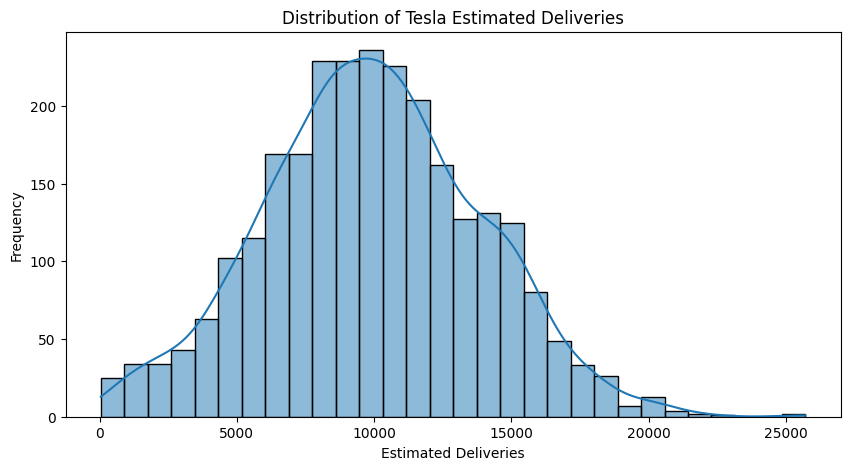

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Estimated_Deliveries"],
    bins=30,
    kde=True
)

plt.title("Distribution of Tesla Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")

plt.show()

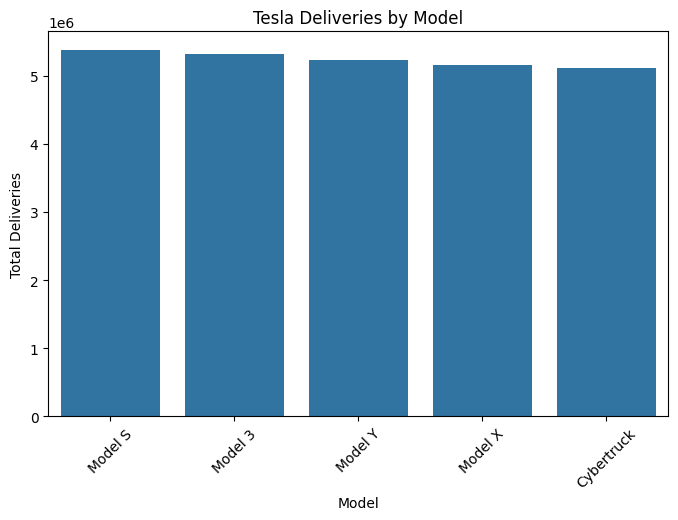

In [8]:
model_sales = (
    df.groupby("Model")["Estimated_Deliveries"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=model_sales.index,
    y=model_sales.values
)

plt.title("Tesla Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Total Deliveries")

plt.xticks(rotation=45)

plt.show()

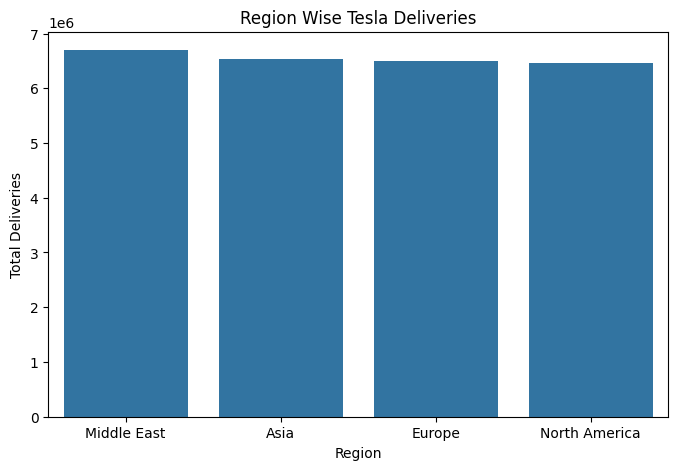

In [9]:
region_sales = (
    df.groupby("Region")["Estimated_Deliveries"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Region Wise Tesla Deliveries")
plt.xlabel("Region")
plt.ylabel("Total Deliveries")

plt.show()

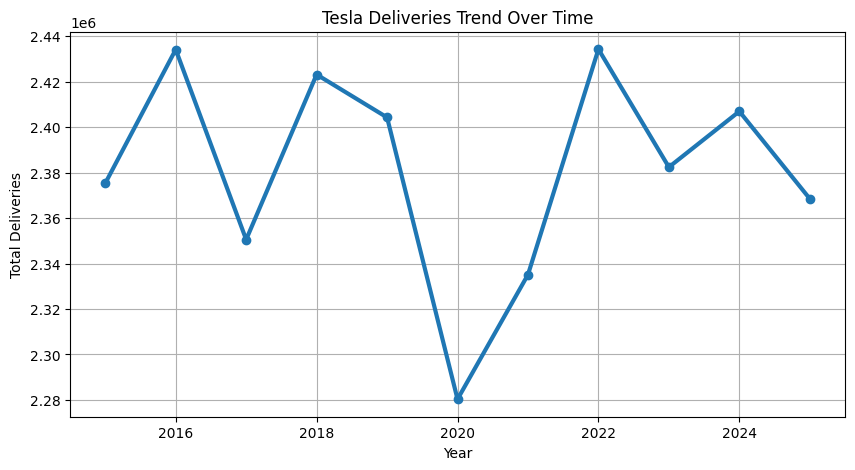

In [10]:
yearly_sales = (
    df.groupby("Year")["Estimated_Deliveries"]
    .sum()
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o",
    linewidth=3
)

plt.title("Tesla Deliveries Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Deliveries")

plt.grid(True)

plt.show()

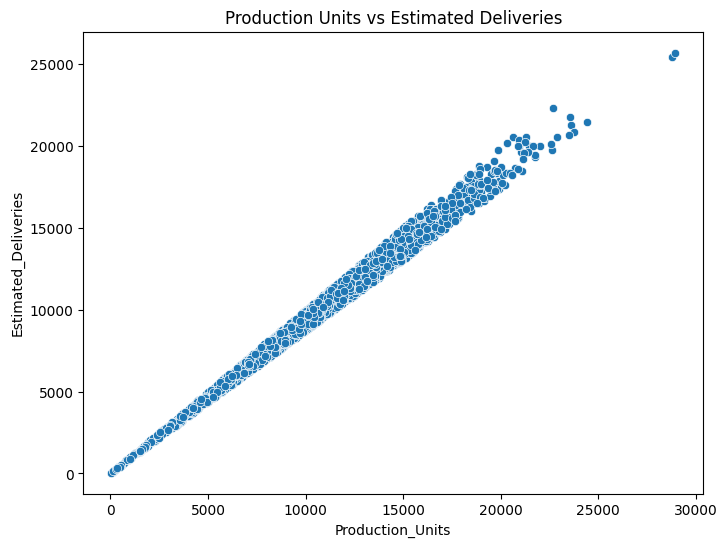

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")

plt.show()

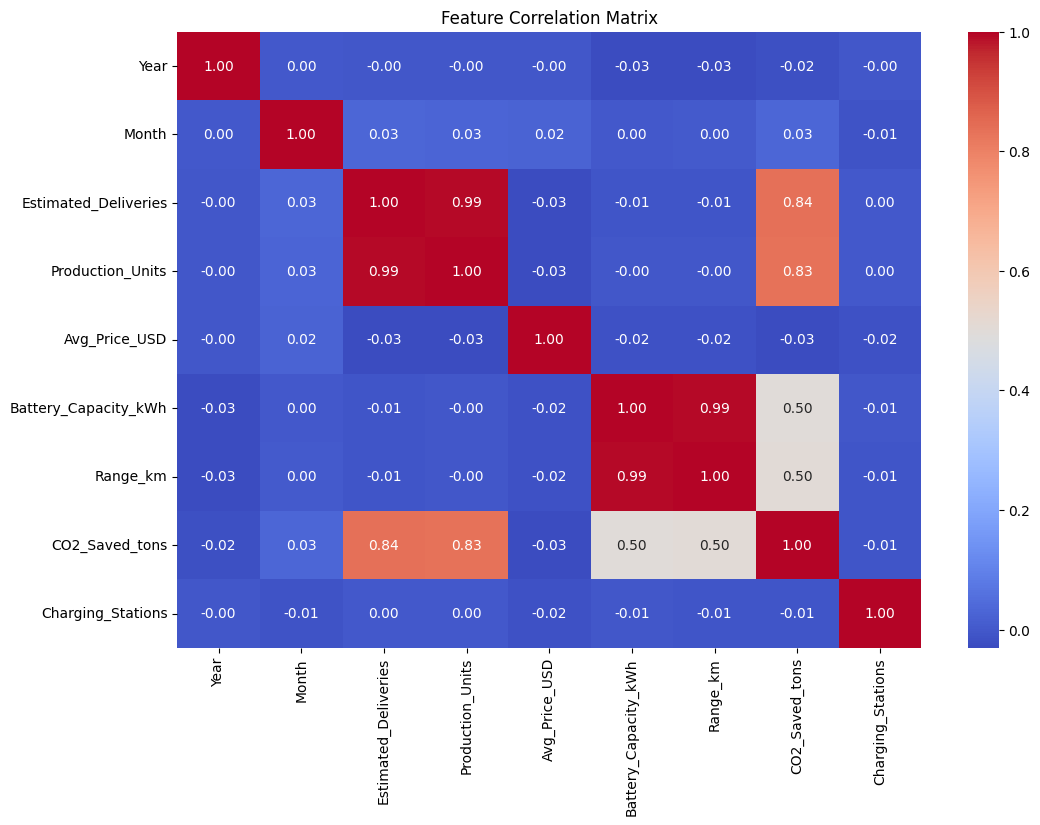

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

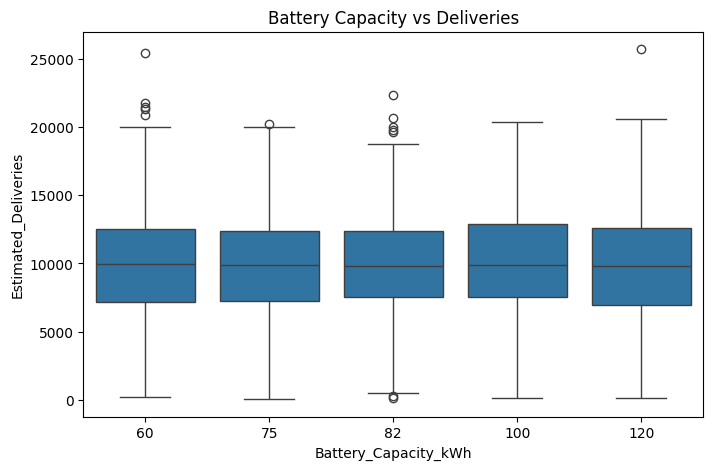

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Battery_Capacity_kWh",
    y="Estimated_Deliveries"
)

plt.title("Battery Capacity vs Deliveries")

plt.show()

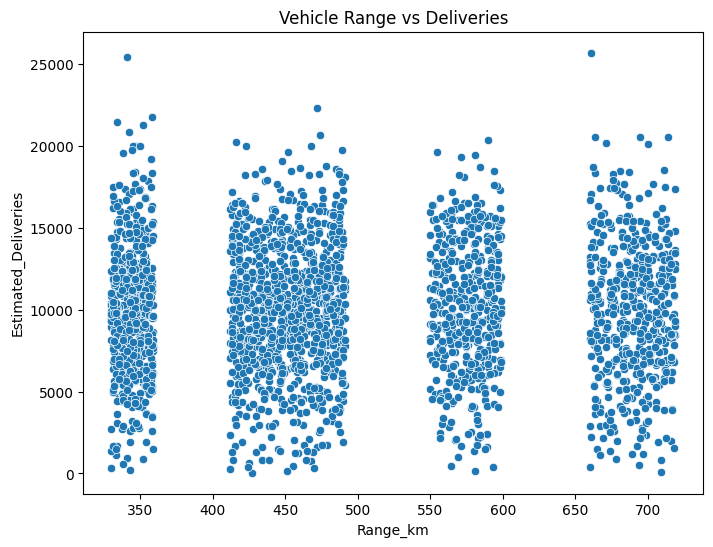

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Range_km",
    y="Estimated_Deliveries"
)

plt.title("Vehicle Range vs Deliveries")

plt.show()

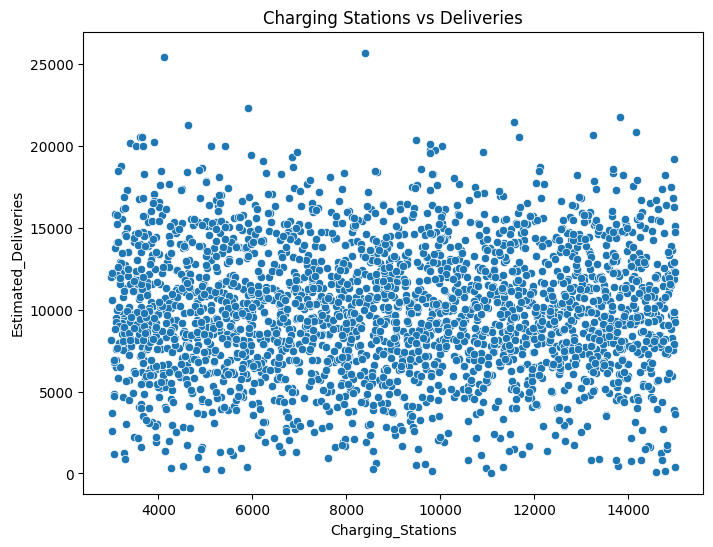

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Charging_Stations",
    y="Estimated_Deliveries"
)

plt.title("Charging Stations vs Deliveries")

plt.show()

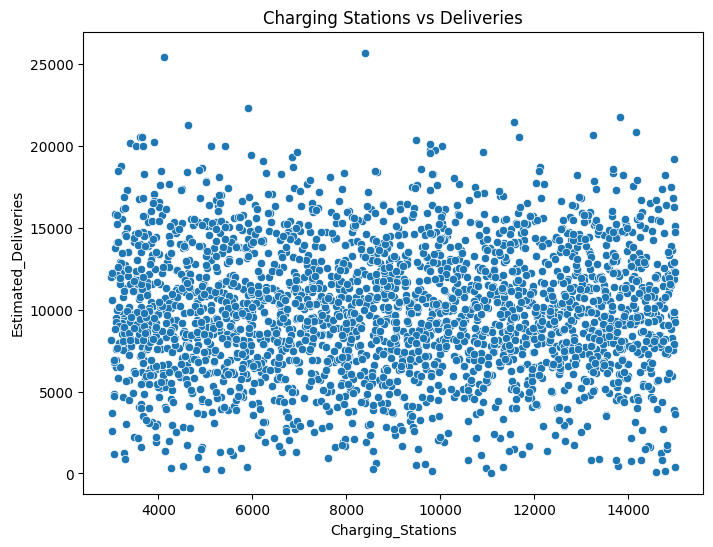

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Charging_Stations",
    y="Estimated_Deliveries"
)

plt.title("Charging Stations vs Deliveries")

plt.show()

In [17]:
top10 = df.nlargest(
    10,
    "Estimated_Deliveries"
)

top10[
    [
        "Year",
        "Region",
        "Model",
        "Estimated_Deliveries"
    ]
]

,Year,Region,Model,Estimated_Deliveries
1341,2017,North America,Model 3,25704
281,2015,Asia,Model 3,25410
725,2015,Middle East,Model Y,22315
2490,2022,Europe,Model Y,21772
729,2018,Europe,Model X,21473
117,2022,Middle East,Model Y,21296
206,2022,Europe,Model 3,20841
2142,2022,North America,Model S,20667
2092,2016,Asia,Model S,20577
1456,2021,North America,Model X,20568


In [18]:
df["Timeline"] = (
    df["Year"] * 12
    + df["Month"]
)

df["Production_Efficiency"] = (
    df["Estimated_Deliveries"]
    /
    df["Production_Units"]
)

df["Price_per_KM"] = (
    df["Avg_Price_USD"]
    /
    df["Range_km"]
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Timeline,Production_Efficiency,Price_per_KM
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,24281,0.984600,131.923679
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,24182,0.911864,142.022032
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,24229,0.915334,245.598583
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,24254,0.896594,125.414199
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,24204,0.914087,173.747020


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Region"] = le.fit_transform(df["Region"])

df["Model"] = le.fit_transform(df["Model"])

df["Source_Type"] = le.fit_transform(df["Source_Type"])

In [20]:
X = df.drop(
    columns=[
        "Estimated_Deliveries",
        "Production_Efficiency"
    ]
)

y = df["Estimated_Deliveries"]

print(X.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type',
       'Charging_Stations', 'Timeline', 'Price_per_KM'],
      dtype='object')


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 13)
(528, 13)


In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Training Complete")


Linear Regression Training Complete


In [23]:
lr_r2 = r2_score(y_test, lr_pred)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

print("R2 Score :", lr_r2)

print("MAE :", lr_mae)

print("RMSE :", lr_rmse)

R2 Score : 0.9901251673010599
MAE : 310.00748943922184
RMSE : 383.6627444562574


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Training Complete")

Random Forest Training Complete


In [25]:
rf_r2 = r2_score(y_test, rf_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

print("R2 Score :", rf_r2)

print("MAE :", rf_mae)

print("RMSE :", rf_rmse)

R2 Score : 0.9884245359904099
MAE : 329.1276325757576
RMSE : 415.3880135604049


In [26]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Training Complete")

XGBoost Training Complete


In [27]:
xgb_r2 = r2_score(y_test, xgb_pred)

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

print("R2 Score :", xgb_r2)

print("MAE :", xgb_mae)

print("RMSE :", xgb_rmse)

R2 Score : 0.9926115870475769
MAE : 251.4022216796875
RMSE : 331.86406526242035


In [28]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "R2 Score":[
        lr_r2,
        rf_r2,
        xgb_r2
    ],

    "MAE":[
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE":[
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score,MAE,RMSE
2,XGBoost,0.992612,251.402222,331.864065
0,Linear Regression,0.990125,310.007489,383.662744
1,Random Forest,0.988425,329.127633,415.388014


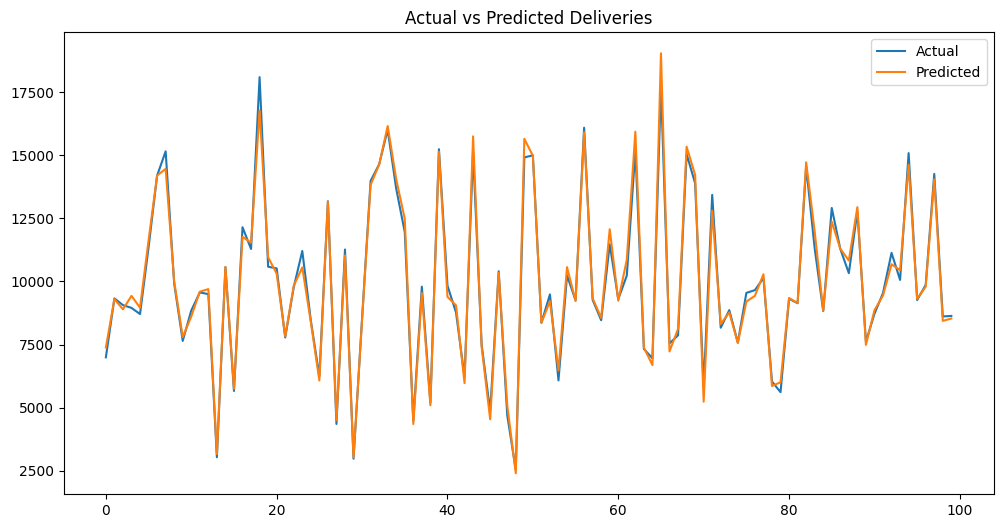

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label="Actual"
)

plt.plot(
    xgb_pred[:100],
    label="Predicted"
)

plt.legend()

plt.title(
    "Actual vs Predicted Deliveries"
)

plt.show()

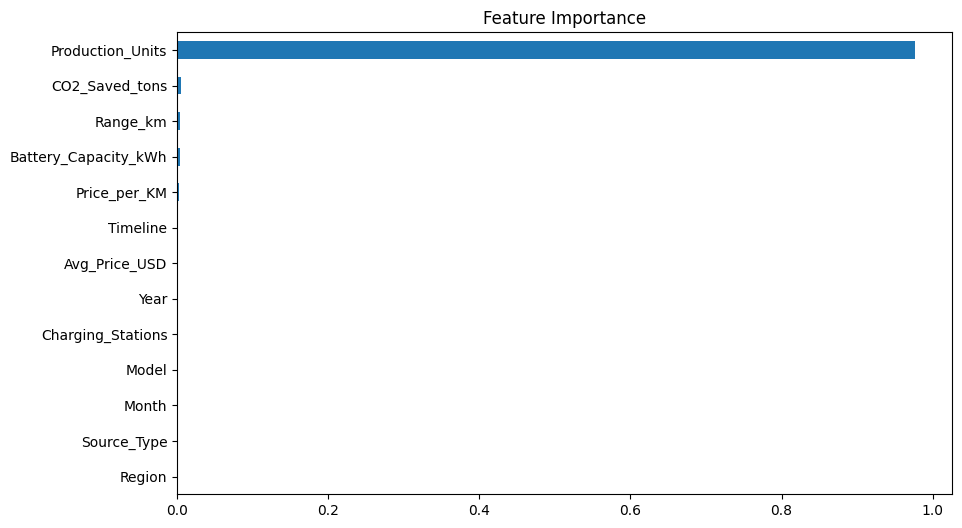

In [30]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

plt.figure(figsize=(10,6))

importance.plot(
    kind="barh"
)

plt.title(
    "Feature Importance"
)

plt.show()

In [31]:
df[["Estimated_Deliveries","Production_Units"]].corr()

,Estimated_Deliveries,Production_Units
Estimated_Deliveries,1.000000,0.994234
Production_Units,0.994234,1.000000


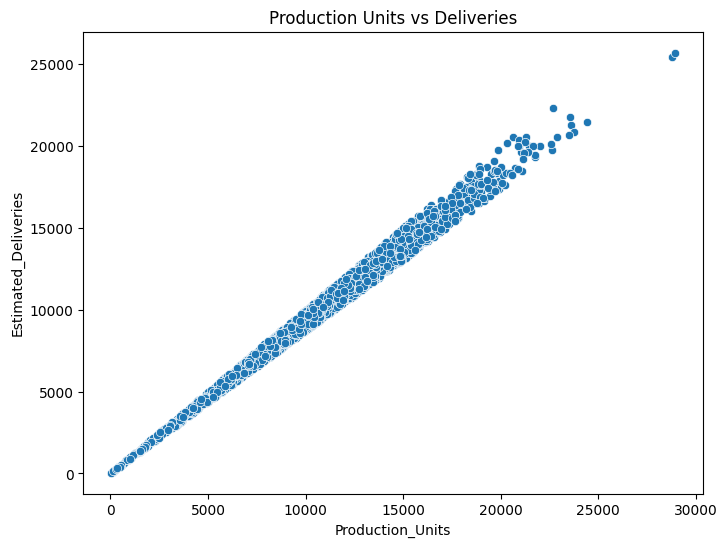

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Production_Units"],
    y=df["Estimated_Deliveries"]
)

plt.title("Production Units vs Deliveries")
plt.show()

In [33]:
results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.990125,310.007489,383.662744
1,Random Forest,0.988425,329.127633,415.388014
2,XGBoost,0.992612,251.402222,331.864065


In [34]:
X.columns

Index(['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type',
       'Charging_Stations', 'Timeline', 'Price_per_KM'],
      dtype='object')

In [35]:
corr_target = (
    df.corr(numeric_only=True)
    ["Estimated_Deliveries"]
    .sort_values(ascending=False)
)

corr_target

Estimated_Deliveries     1.000000
Production_Units         0.994234
CO2_Saved_tons           0.836814
Month                    0.030877
Model                    0.004515
Production_Efficiency    0.000929
Charging_Stations        0.000753
Timeline                -0.000054
Region                  -0.001206
Year                    -0.002863
Range_km                -0.006606
Battery_Capacity_kWh    -0.007765
Source_Type             -0.013190
Price_per_KM            -0.019372
Avg_Price_USD           -0.027546
Name: Estimated_Deliveries, dtype: float64

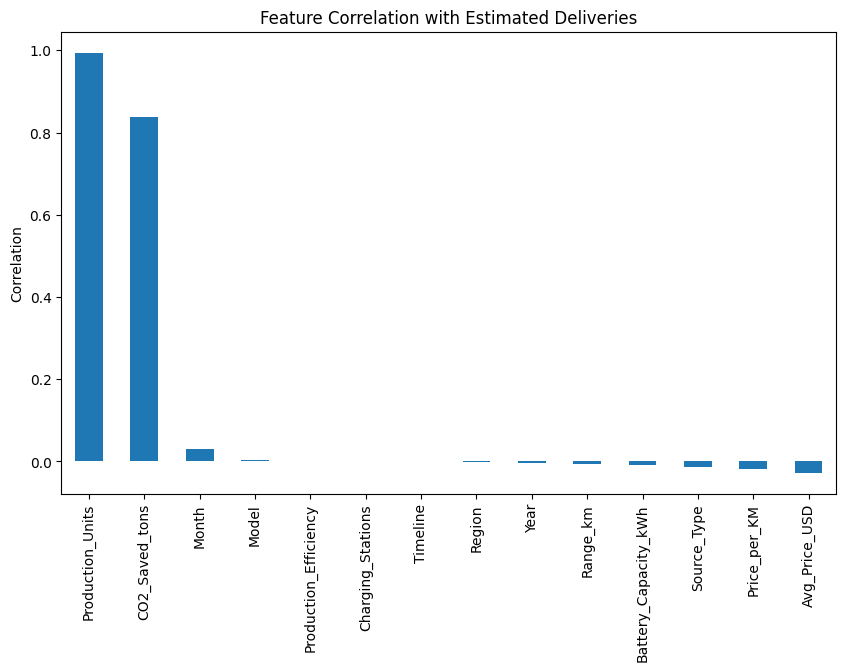

In [36]:
plt.figure(figsize=(10,6))

corr_target[1:].plot(
    kind="bar"
)

plt.title(
    "Feature Correlation with Estimated Deliveries"
)

plt.ylabel("Correlation")

plt.show()

In [37]:
best_model = "XGBoost"

print("Best Model:", best_model)

print("R2 Score:", xgb_r2)

print("MAE:", xgb_mae)

print("RMSE:", xgb_rmse)

Best Model: XGBoost
R2 Score: 0.9926115870475769
MAE: 251.4022216796875
RMSE: 331.86406526242035


In [38]:
yearly_sales = (
    df.groupby("Year")
    ["Estimated_Deliveries"]
    .sum()
)

yearly_sales

Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64

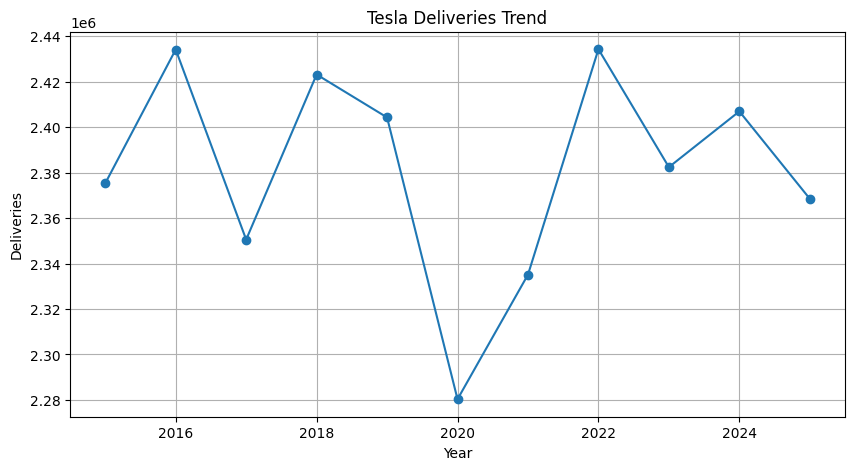

In [39]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o"
)

plt.title(
    "Tesla Deliveries Trend"
)

plt.xlabel("Year")

plt.ylabel("Deliveries")

plt.grid()

plt.show()

In [40]:
from sklearn.linear_model import LinearRegression

trend_df = yearly_sales.reset_index()

X_time = trend_df[["Year"]]

y_time = trend_df["Estimated_Deliveries"]

forecast_model = LinearRegression()

forecast_model.fit(
    X_time,
    y_time
)

LinearRegression()

In [41]:
forecast_2026 = forecast_model.predict(
    [[2026]]
)

print(
    "Predicted Deliveries for 2026:",
    int(forecast_2026[0])
)

Predicted Deliveries for 2026: 2376197


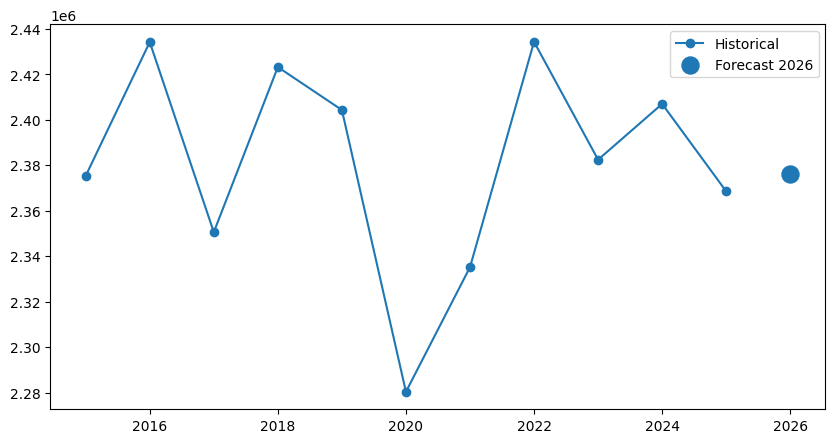

In [42]:
future_years = pd.DataFrame({
    "Year":[2026]
})

future_pred = forecast_model.predict(
    future_years
)

plt.figure(figsize=(10,5))

plt.plot(
    trend_df["Year"],
    trend_df["Estimated_Deliveries"],
    marker="o",
    label="Historical"
)

plt.scatter(
    2026,
    future_pred[0],
    s=150,
    label="Forecast 2026"
)

plt.legend()

plt.show()

Conclusion
Production Units emerged as the most influential feature affecting Tesla deliveries.
XGBoost achieved the highest prediction accuracy with an R² score of 0.9926.
Tesla deliveries exhibited a strong relationship with production capacity.
Correlation analysis and feature importance confirmed the dominance of operational variables over product specifications.
A forecasting model was developed to estimate future Tesla deliveries for 2026.